In [1]:
# Imports as always...
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset,DataLoader
import torch.optim as optim

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cmcrameri.cm as cmc

import warnings
warnings.filterwarnings('ignore')

device = 'mps' if torch.mps.is_available() else 'cpu'

In [2]:
# Consistent colours.
colours = cmc.berlin([0, .3, 1])

# Helper function to let us adjust the colours for plotting.
def adjust_brightness(color, factor):
    rgb = np.array(mcolors.to_rgb(color))
    rgb = np.clip(rgb * factor, 0, 1)
    return rgb

# Fingerprint Sequencing

In [3]:
class SequenceDataset(Dataset):
    def __init__(self, df : pd.DataFrame, prior_length : int, qpu_filter : str | None = None):
        assert prior_length < df.step.max()

        # (Optionally) Filter devices.
        if qpu_filter:
            df = df[df['device'] == qpu_filter]

        # Order by completion time.
        df = df.sort_values(['device', 'completion_time']).reset_index(drop=True)

        # Encode device labels.
        qpus = sorted(df['device'].unique())
        self.qpu_label_encoding = {d : i for i, d in enumerate(qpus)}

        # Group by device.
        self.samples = []
        for qpu, group in df.groupby('device'):
            group = group.sort_values('completion_time')
            qpu_label = self.qpu_label_encoding[qpu]
            probs = group[list(filter(lambda x : x.startswith('x'), df.columns))].to_numpy(np.float32)

            # Normalise, just in case.
            probs /= probs.sum(axis=1, keepdims=True)

            # Sliding windows.
            for i in range(len(probs) - prior_length):
                self.samples.append((
                    probs[i : i + prior_length], # Prior.
                    probs[i + prior_length],     # Target.
                    qpu_label
                ))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        xs, y, label = self.samples[idx]
        return (
            torch.tensor(xs, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32),
            torch.tensor(label, dtype=torch.long)
        )

In [4]:
# Read in data.
data_df = pd.read_csv('./data/time-varied/Master.csv')
display(data_df)

# PyTorch-ify.
dataset = SequenceDataset(data_df, prior_length=10, qpu_filter='Ankaa-3')
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

,index,n,step,batch,n_shots,device,task_id,completion_time,x00000,x00001,...,x10110,x10111,x11000,x11001,x11010,x11011,x11100,x11101,x11110,x11111
0,0,5,1,1,1024,Ankaa-3,arn:aws:braket:us-west-1:745438739765:quantum-...,2025-08-06T01:41:30.594Z,0.410156,0.029297,...,0.010742,0.017578,0.004883,0.001953,0.001953,0.026367,0.007812,0.026367,0.015625,0.359375
1,1,5,2,1,1024,Ankaa-3,arn:aws:braket:us-west-1:745438739765:quantum-...,2025-08-06T01:41:31.123Z,0.433594,0.019531,...,0.009766,0.021484,0.007812,0.004883,0.001953,0.027344,0.001953,0.021484,0.018555,0.328125
2,2,5,3,1,1024,Ankaa-3,arn:aws:braket:us-west-1:745438739765:quantum-...,2025-08-06T01:41:32.032Z,0.420898,0.029297,...,0.011719,0.015625,0.000977,0.002930,0.002930,0.027344,0.000977,0.020508,0.019531,0.338867
3,3,5,4,1,1024,Ankaa-3,arn:aws:braket:us-west-1:745438739765:quantum-...,2025-08-06T01:41:31.477Z,0.398438,0.017578,...,0.005859,0.023438,0.002930,0.004883,0.000977,0.033203,0.003906,0.028320,0.017578,0.367188
4,4,5,5,1,1024,Ankaa-3,arn:aws:braket:us-west-1:745438739765:quantum-...,2025-08-06T01:41:31.815Z,0.419922,0.023438,...,0.008789,0.018555,0.002930,0.002930,0.000977,0.022461,0.006836,0.025391,0.016602,0.342773
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
640,95,5,96,3,1024,Garnet,arn:aws:braket:eu-north-1:745438739765:quantum...,2025-08-11T00:00:39.198Z,0.451172,0.025391,...,0.004883,0.011719,0.000000,0.000977,0.002930,0.010742,0.004883,0.037109,0.009766,0.381836
641,96,5,97,3,1024,Garnet,arn:aws:braket:eu-north-1:745438739765:quantum...,2025-08-11T00:00:53.703Z,0.422852,0.012695,...,0.001953,0.014648,0.000977,0.003906,0.000977,0.018555,0.004883,0.037109,0.011719,0.418945
642,97,5,98,3,1024,Garnet,arn:aws:braket:eu-north-1:745438739765:quantum...,2025-08-11T00:01:33.666Z,0.425781,0.012695,...,0.001953,0.009766,0.000000,0.002930,0.002930,0.021484,0.002930,0.050781,0.019531,0.387695
643,98,5,99,3,1024,Garnet,arn:aws:braket:eu-north-1:745438739765:quantum...,2025-08-11T00:01:10.201Z,0.482422,0.019531,...,0.000977,0.017578,0.000000,0.000977,0.003906,0.021484,0.000977,0.032227,0.007812,0.361328


In [5]:
class LSTM(nn.Module):
    def __init__(self, hidden_dim : int = 128, n_layers : int = 3, dropout : float = .5):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=32,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout
        )

        self.fc = nn.Linear(hidden_dim, 32)

    def forward(self, x):
        out, _ = self.lstm(x)

        # Look at the last hidden state (the prediction)
        last = out[:, -1, :]

        # Fully-connected + softmax.
        logits = self.fc(last)
        return F.softmax(logits, dim=-1)

In [6]:
def train(model, loader, n_epochs=20, lr=1e-3, verbose=False):
    model.to(device)
    optimiser = optim.Adam(model.parameters(), lr=lr)

    for epoch in tqdm(range(1, n_epochs + 1)):
        model.train()
        total_loss = .0

        for x, y_true, _ in loader:
            x, y_true = x.to(device), y_true.to(device)

            optimiser.zero_grad()
            y_pred = model(x)

            # KL divergence (predicted vs. true distribution)
            loss = F.kl_div(y_pred.log(), y_true, reduction='batchmean')

            loss.backward()
            optimiser.step()

            total_loss += loss.item() * x.size(0)

        avg_loss = total_loss / len(loader.dataset)
        if verbose:
            if epoch % 10 == 0:
                print(f'Epoch {epoch:02d} | Loss: {avg_loss:.6f}')

model = LSTM(512, 10, .8)
train(model, dataloader, n_epochs=100, lr=1e-4, verbose=True)

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch 10 | Loss: 0.024297
Epoch 20 | Loss: 0.024263
Epoch 30 | Loss: 0.024376
Epoch 40 | Loss: 0.024295
Epoch 50 | Loss: 0.024277
Epoch 60 | Loss: 0.024297
Epoch 70 | Loss: 0.024379
Epoch 80 | Loss: 0.024435
Epoch 90 | Loss: 0.024266
Epoch 100 | Loss: 0.024251


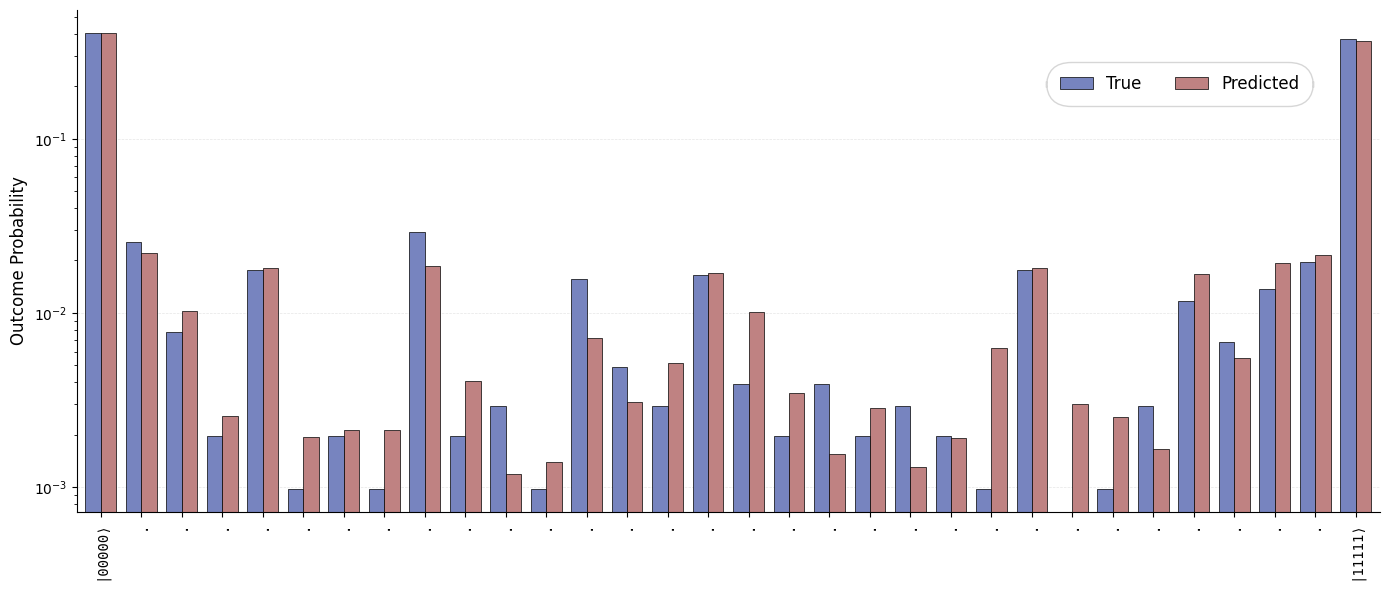

In [8]:
def plot_distribution_comparison(
    true_probs, pred_probs, state_labels=None, save_file=None
):
    """Compare true vs.

    predicted probability distributions side-by-side with an academic publication
    style.
    """
    # 1. Ensure CPU numpy arrays
    if isinstance(true_probs, torch.Tensor):
        true_probs = true_probs.detach().cpu().numpy()
    if isinstance(pred_probs, torch.Tensor):
        pred_probs = pred_probs.detach().cpu().numpy()

    true_probs = np.clip(true_probs, 0, 1)
    pred_probs = np.clip(pred_probs, 0, 1)

    n_states = len(true_probs)
    x = np.arange(n_states)

    if state_labels is None:
        # Standard format for 5-bit strings (32 states)
        state_labels = [f"|{format(i, '05b')}⟩" if (i == 0 or i == n_states - 1 ) else "." for i in range(n_states)]

    # Academic papers typically use single-column (3.5 in) or double-column (7 in) widths.
    # For 32 states, we need a wider view, so ~7.5 inches works beautifully.
    fig, ax = plt.subplots(figsize=(14, 6))

    # 3. Color Palette (Muted, professional, high-contrast)
    color_true = adjust_brightness(colours[0], .75)
    color_pred = adjust_brightness(colours[2], .75)

    # 4. Plotting Bars with slight overlap/gap tuning
    width = 0.38  # Leave a tiny gap between pairs
    rects1 = ax.bar(
        x - width / 2,
        true_probs,
        width,
        label="True",
        color=color_true,
        edgecolor="black",
        linewidth=0.5,
    )
    rects2 = ax.bar(
        x + width / 2,
        pred_probs,
        width,
        label="Predicted",
        color=color_pred,
        edgecolor="black",
        linewidth=0.5,
    )

    # 5. Labels and Typography
    ax.set_ylabel("Outcome Probability", fontsize=12)
    ax.set_xticks(x)

    # 6. Grid and Spines (Removing chart junk)
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle="--", alpha=0.5, color="#cccccc")
    ax.xaxis.grid(False)

    # Despine top and right
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)

    # 7. Axis Ticks Tuning
    ax.set_xticks(x)
    ax.set_xticklabels(
        state_labels, rotation=90, family="monospace"
    )
    ax.tick_params(axis="y")

    # Fix limits slightly to give breathing room on edges
    ax.set_xlim(-0.6, n_states - 0.4)

    ax.set_yscale("log")

    # 8. Legend Formatting
    leg = plt.legend(
    loc='upper right', bbox_to_anchor=(.95, 0.90),
    fontsize=12,
    frameon=True,
    fancybox=True,
    framealpha=.8,
    facecolor='white',
    ncol=2,
    )
    frame = leg.get_frame()
    frame.set_boxstyle('round', pad=0.4, rounding_size=1.5)

    if save_file is not None:
        plt.savefig(save_file, bbox_inches='tight')

    plt.tight_layout()
    plt.show()

# Evaluation / visualization
model.eval()
with torch.no_grad():
    for x, y, device_label in dataloader:
        x = x.to(device)
        y = y.to(device)
        pred = model(x)

        true_probs = y[1]
        pred_probs = pred[1]
        plot_distribution_comparison(true_probs, pred_probs, save_file='./figures/sequencing/predicted_outcome_example.pdf')
        break

In [15]:
class TimeAwareSequenceDataset(Dataset):
    def __init__(self, df: pd.DataFrame, prior_length: int = 5):
        assert prior_length < df.step.max()

        self.prior_length = prior_length

        # Order by completion time.
        df = df.sort_values('completion_time').reset_index(drop=True)
        self.df = df.copy()

        # Note which columns are distribution columns.
        self.prob_columns = [c for c in df.columns if c.startswith('x')]

        # Times as numerics (seconds).
        self.df['timestamp'] = pd.to_datetime(self.df['completion_time']).astype(np.int64) / 1e9

        # Specify which indices have enough history to be sampled.
        self.valid_indices = list(range(prior_length, len(df)))

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        target_idx = self.valid_indices[idx]
        past_idx = range(target_idx - self.prior_length, target_idx)

        # Slice rows.
        target_row = self.df.iloc[target_idx]
        past_rows = self.df.iloc[list(past_idx)]

        # Compute relative time offsets.
        relative_times = (past_rows['timestamp'].values - target_row['timestamp']).astype(np.float32)

        # Features and target.
        xs = np.hstack([relative_times[:, None], past_rows[self.prob_columns].to_numpy(np.float32)])
        y = target_row[self.prob_columns].to_numpy(np.float32)

        return torch.tensor(xs, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

In [16]:
class RelativeLSTM(nn.Module):
    def __init__(self, input_dim=33, hidden_dim=64, num_layers=2, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
        )
        self.fc = nn.Linear(hidden_dim, 32)

    def forward(self, x):
        out, _ = self.lstm(x)
        last = out[:, -1, :]
        logits = self.fc(last)
        probs = F.softmax(logits, dim=-1)
        return probs

In [17]:
data_df["completion_time"] = pd.to_datetime(data_df["completion_time"])
data_df = data_df.sort_values("completion_time").reset_index(drop=True)

time_split_ratio = 0.8
split_idx = int(len(data_df) * time_split_ratio)

df_train = data_df.iloc[:split_idx].reset_index(drop=True)
df_val = data_df.iloc[split_idx:].reset_index(drop=True)

seq_len = 5
train_dataset = TimeAwareSequenceDataset(df_train, seq_len)
val_dataset   = TimeAwareSequenceDataset(df_val, seq_len)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples:   {len(val_dataset)}")

Train samples: 511
Val samples:   124


In [20]:
from IPython.display import clear_output

def train(
    model,
    train_dataset,
    val_dataset,
    num_epochs=50,
    batch_size=32,
    lr=1e-3,
    plot_every=1,
):
    """
    Train model with live plotting inside a Jupyter notebook.
    Updates the loss plot inline after each epoch.
    """
    # --- Device setup ---
    model = model.to(device)

    # --- DataLoaders ---
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # --- Loss & optimizer ---
    criterion = nn.KLDivLoss(reduction="batchmean")
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # --- Stats ---
    train_losses, val_losses = [], []

    for epoch in range(1, num_epochs + 1):
        model.train()
        running_train_loss = 0.0

        for x, y_true in train_loader:
            x, y_true = x.to(device), y_true.to(device)
            optimizer.zero_grad()
            y_pred = model(x)
            loss = criterion(torch.log(y_pred + 1e-12), y_true)
            loss.backward()
            optimizer.step()
            running_train_loss += loss.item() * x.size(0)

        avg_train_loss = running_train_loss / len(train_loader.dataset)
        train_losses.append(avg_train_loss)

        # --- Validation ---
        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for x, y_true in val_loader:
                x, y_true = x.to(device), y_true.to(device)
                y_pred = model(x)
                loss = criterion(torch.log(y_pred + 1e-12), y_true)
                running_val_loss += loss.item() * x.size(0)

        avg_val_loss = running_val_loss / len(val_loader.dataset)
        val_losses.append(avg_val_loss)

        # --- Print progress ---
        if epoch % plot_every == 0:
            print(f"Epoch [{epoch}/{num_epochs}] "
                  f"Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f}")

        # --- Inline plot update ---
        if epoch % plot_every == 0:
            clear_output(wait=True)
            plt.figure(figsize=(7, 4))
            plt.plot(train_losses, label="Train", color="blue")
            plt.plot(val_losses, label="Validation", color="orange")
            plt.yscale('log')
            plt.xlabel("Epoch")
            plt.ylabel("KLDiv Loss")
            plt.title("Training and Validation Loss")
            plt.legend()
            plt.grid(True, linestyle='--', alpha=0.4)
            plt.tight_layout()
            plt.show()

    return {"train_losses": train_losses, "val_losses": val_losses}

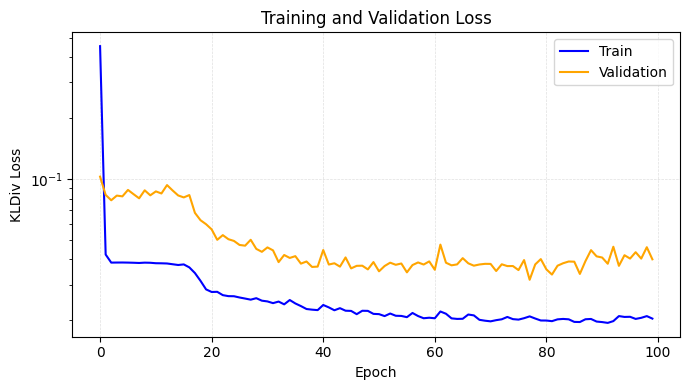

In [21]:
model = RelativeLSTM(input_dim=33, hidden_dim=128)
stats = train(
    model,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    num_epochs=100,
    batch_size=16,
    lr=1e-3,
    plot_every=10,
)

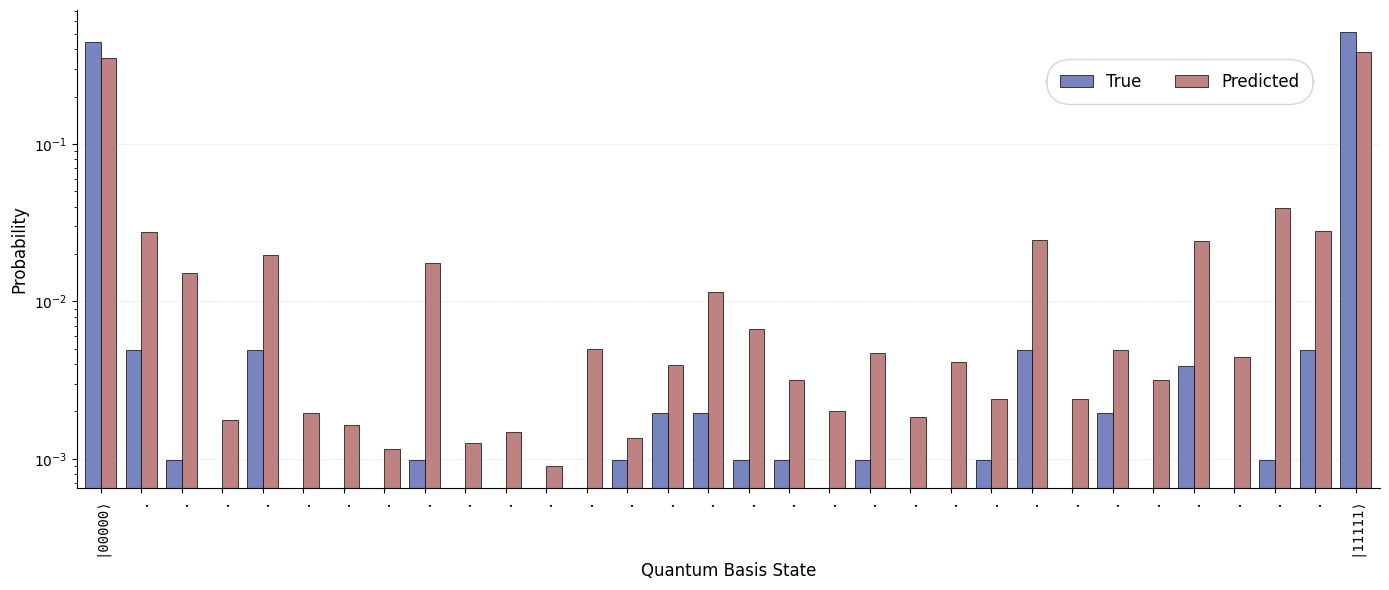

In [35]:
# Evaluation / visualization
model.eval()

# --- Fetch and move data ---
x, y_true = val_dataset[5]
x = x.unsqueeze(0).to(device)         # [1, seq_len, 33]
y_true = y_true.unsqueeze(0).to(device)  # [1, 32]

# --- Forward pass ---
with torch.no_grad():
    y_pred = model(x)

# --- Move to CPU for plotting ---
y_true_np = y_true.squeeze(0).detach().cpu().numpy()
y_pred_np = y_pred.squeeze(0).detach().cpu().numpy()

plot_distribution_comparison(y_true_np, y_pred_np)